## Merge Reports
Parse all `logs/debug_real2sim*` folders, read the CSVs in the `reports` subfolders, and merge them into one large CSV.

In [1]:
import pandas as pd
import glob
import os
import yaml
from collections import defaultdict

def get_task_perturbations():
    task_perts = defaultdict(list)
    # Search the realm/config/tasks/IMPACT directory
    task_dirs = glob.glob('realm/config/tasks/IMPACT/*/')
    for task_dir in task_dirs:
        task_name = os.path.basename(os.path.normpath(task_dir))
        yaml_files = glob.glob(os.path.join(task_dir, '*.yaml'))
        for yf in yaml_files:
            pert_name = os.path.splitext(os.path.basename(yf))[0]
            if pert_name.lower() == 'default':
                pert_name = 'Default'
            task_perts[task_name].append(pert_name)
    return task_perts

def process_and_merge_reports(drop_sim_drawers=True):
    all_dfs = []
    main_csv_path = 'real2sim_perf_data/merged_debug_reports.csv'

    task_perts = get_task_perturbations()
    
    # 2. Process CSVs from logs/abblations directories ONLY
    log_csv_files = glob.glob('logs/abblations*/**/*.csv', recursive=True)
    for file in log_csv_files:
        try:
            df = pd.read_csv(file)
            df['source_file'] = file
            all_dfs.append(df)
        except Exception as e:
            print(f"Error reading log CSV {file}: {e}")

    # 3. Process external CSVs from real2sim_perf_data/ (excluding the main merged file)
    external_csv_files = glob.glob('real2sim_perf_data/*.csv')
    external_csv_files = [f for f in external_csv_files if 'merged_debug_reports.csv' not in f]
    for file in external_csv_files:
        try:
            df = pd.read_csv(file)
            df['source_file'] = file
            df.columns = [col.lower() for col in df.columns]
            all_dfs.append(df)
        except Exception as e:
            print(f"Error reading external CSV {file}: {e}")

    if not all_dfs:
        print("No CSV files found to process.")
        return

    # Concatenate all dataframes
    merged_df = pd.concat(all_dfs, ignore_index=True)

    # 4. Apply transformations
    if 'perturbation' not in merged_df.columns:
        merged_df['perturbation'] = 'Default'

    def parse_task_perturbation(row):
        task_name = str(row['task'])
        parts = task_name.rsplit('_', 1)
        if len(parts) == 2:
            base_task = parts[0]
            pert = parts[1]
            if base_task in task_perts and pert in task_perts[base_task]:
                row['task'] = base_task
                row['perturbation'] = pert
        return row
    merged_df = merged_df.apply(parse_task_perturbation, axis=1)

    model_mapping = {
        'ckpt_pi0_fast_droid_jointpos': 'FAST',
        'pi0_droid_jointpos_pi0_droid_jointpos': 'FM',
        'GROOT': 'GR00T'
    }
    if 'model' in merged_df.columns:
        merged_df['model'] = merged_df['model'].replace(model_mapping)
        merged_df = merged_df[merged_df['model'] != 'debug']

    def parse_model_from_path(row):
        source_file = str(row.get('source_file', '')).replace('\\', '/')
        if source_file.startswith('logs/abblations/'):
            parts = source_file.split('/')
            if len(parts) > 3:
                return parts[3]
        elif source_file.startswith('real2sim_perf_data/'):
            filename = os.path.basename(source_file)
            if 'FAST' in filename:
                return 'FAST'
            elif 'FM' in filename:
                return 'FM'
            elif 'GROOT' in filename or 'GR00T' in filename:
                return 'GR00T'
        return row.get('model', 'Unknown')
    
    if 'model' in merged_df.columns:
        merged_df['model'] = merged_df.apply(parse_model_from_path, axis=1)

    def extract_exp_name(source_file):
        if pd.isna(source_file):
            return None
        source_file = source_file.replace('\\', '/')
        if source_file.startswith('logs/abblations'):
            parts = source_file.split('/')
            if len(parts) > 2:
                return parts[2]
            return parts[1]
        elif source_file.startswith('real2sim_perf_data/'):
            return os.path.splitext(os.path.basename(source_file))[0]
        return None
    merged_df['experiment_name'] = merged_df['source_file'].apply(extract_exp_name)
    
    # FILTER OUT trajectory_replay
    if 'task' in merged_df.columns:
        merged_df = merged_df[merged_df['task'] != 'trajectory_replay']
        
    merged_df['perturbation'] = merged_df['perturbation'].fillna('Default')
    if 'real2sim' in merged_df.columns:
        merged_df['real2sim'] = merged_df['real2sim'].fillna('Unknown')
        
    # Standardize real2sim column text
    merged_df['real2sim'] = merged_df['real2sim'].apply(lambda x: str(x).capitalize() if pd.notnull(x) else x)
    
    # Rename experiment_name for GROOT, Pi0_FM, Pi0_FAST
    baseline_exps = ['GROOT', 'Pi0_FM', 'Pi0_FAST']
    is_baseline = merged_df['experiment_name'].isin(baseline_exps)
    
    # For baseline exps, if real2sim == 'Real', experiment_name becomes 'Real'
    # If real2sim != 'Real' (i.e., 'Simulated'), experiment_name becomes 'rt_orig'
    real_mask = is_baseline & (merged_df['real2sim'] == 'Real')
    sim_mask = is_baseline & (merged_df['real2sim'] != 'Real')
    
    merged_df.loc[real_mask, 'experiment_name'] = 'Real'
    merged_df.loc[sim_mask, 'experiment_name'] = 'rt_orig'

    if drop_sim_drawers:
        drawer_tasks = ['open_the_drawer', 'close_the_drawer']
        merged_df = merged_df[~((merged_df['task'].isin(drawer_tasks)) & (merged_df['real2sim'] != 'Real'))]

    merged_df.to_csv(main_csv_path, index=False)
    print(f"Final processed data saved to {main_csv_path}. Total rows: {len(merged_df)}")

process_and_merge_reports()


Final processed data saved to real2sim_perf_data/merged_debug_reports.csv. Total rows: 4170


In [2]:
# import pandas as pd
# import glob
# import os

# df = pd.read_csv('real2sim_perf_data/merged_debug_reports.csv')

# # Define expected combinations
# ALL_MODELS = ['GR00T', 'FM', 'FAST']
# ALL_EXPERIMENTS = ['Real', 'r', 'rt', 'pt', 'default_pd', 'polaris_pd']

# # Get task and perturbations from YAMLs
# task_perts = {}
# task_dirs = glob.glob('realm/config/tasks/IMPACT/*/')
# for task_dir in task_dirs:
#     task_name = os.path.basename(os.path.normpath(task_dir))
#     yaml_files = glob.glob(os.path.join(task_dir, '*.yaml'))
#     perts = []
#     for yf in yaml_files:
#         pert_name = os.path.splitext(os.path.basename(yf))[0]
#         if pert_name.lower() == 'default':
#             pert_name = 'Default'
#         perts.append(pert_name)
#     if perts:
#         task_perts[task_name] = perts

# # Generate all expected combinations
# expected_combos = []
# for model in ALL_MODELS:
#     for exp in ALL_EXPERIMENTS:
#         for task, perts in task_perts.items():
#             for pert in perts:
#                 # Based on filtering logic, baseline experiment='Real' -> real2sim='Real'
#                 # Ablations (r, rt, pt, etc) -> real2sim='Simulated'
#                 expected_real2sim = 'Real' if exp == 'Real' else 'Simulated'
#                 expected_combos.append((model, exp, task, pert, expected_real2sim))

# # Check actual data
# actual_counts = df.groupby(['model', 'experiment_name', 'task', 'perturbation', 'real2sim']).size().to_dict()

# print(f"{'model':<10} {'experiment':<15} {'task':<30} {'perturbation':<15} {'real2sim':<15} {'count'}")
# print("-" * 95)
# less_than_5 = []

# for combo in expected_combos:
#     model, exp, task, pert, real2sim = combo
#     count = actual_counts.get(combo, 0)
#     print(f"{model:<10} {exp:<15} {task:<30} {pert:<15} {real2sim:<15} {count}")
#     if count < 3:
#         less_than_5.append((combo, count))

# print("\n" + "="*50)
# print("COMBINATIONS WITH FEWER THAN 5 SAMPLES")
# print("="*50)
# for combo, count in less_than_5:
#     model, exp, task, pert, real2sim = combo
#     print(f"{model:<10} {exp:<15} {task:<30} {pert:<15} {real2sim:<15} COUNT: {count}")


## Plotting

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [12]:
green = "#C8E6C9"
yellow = "#FFF9C4"
purple = "#b35cfa" #"#E6E6FA"
pink = "#f696ff" #"#FFA07A"
orange = "#FFE0B2"
blue = "#BBDEFB"
red = "#F08080"

models = ['FM', 'FAST', 'GR00T']
model_markers = {'FAST': 'D', 'FM': 's', 'GR00T': '^'}

task_details = {
    'put_green_block_in_bowl': {'color': 'green'},
    'pick_spoon': {'color': 'blue'},
    'stack_cubes': {'color': 'red'},
    'rotate_marker': {'color': 'orange'},
    'put_banana_into_box': {'color': 'purple'},
    'open_the_drawer': {'color': 'brown'},
    'close_the_drawer': {'color': 'cyan'}
}

model_latex = {
    'GR00T': 'GR00T N1.5',
    'FM': '$\pi_0$',
    'FAST': '$\pi_0$-FAST',
}

experiment_titles_rendering = {
    'r': "Rasterization-like",
    'rt': "Ray Tracing",
    'rt_orig': "Ray Tracing",
    'pt': "Path Tracing",
}

experiment_titles_control = {
    'rt': "Our controller alignment",
    'rt_orig': "Our controller alignment",
    'default_pd': "Default PD controller",
    'polaris_pd': "Polaris PD controller"
}

task_details = {
    'put_green_block_in_bowl': {'color': green, 'label': 'Put block into bowl'},
    'put_banana_into_box': {'color': yellow, 'label': 'Put banana into box'},
    'open_the_drawer': {'color': pink, 'label': 'Open drawer'},
    'close_the_drawer': {'color': purple, 'label': 'Close drawer'},
    'stack_cubes': {'color': orange, 'label': 'Stack cubes'},
    'rotate_marker': {'color': blue, 'label': 'Rotate marker'},
    'pick_spoon': {'color': red, 'label': 'Pick spoon'},
}

all_perturbations = ['De', 'CP', 'DS', 'LT', 'PS', 'RS', 'TT']

In [13]:
# Load data
df = pd.read_csv("real2sim_perf_data/merged_debug_reports.csv")
df["perturbation"] = df["perturbation"].fillna("Default")

# Fix missing binary_SR for Real experiments
real_mask = df["experiment_name"] == "Real"
df.loc[real_mask, "binary_SR"] = df.loc[real_mask, "binary_SR"].fillna((df.loc[real_mask, "task_progression"] >= 1.0).astype(float))

# Group by model, experiment, task, perturbation and get means
grouped = df.groupby(["model", "experiment_name", "task", "perturbation"]).agg({
    "binary_SR": "mean",
    "task_progression": "mean"
}).reset_index()

# Average over perturbations to get model / experiment / task triplets
averaged = grouped.groupby(["model", "experiment_name", "task"]).agg({
    "binary_SR": "mean",
    "task_progression": "mean"
}).reset_index()

real_data = averaged[averaged["experiment_name"] == "Real"].copy()
real_data.rename(columns={"binary_SR": "real_binary_SR", "task_progression": "real_task_progression"}, inplace=True)
real_data.drop(columns=["experiment_name"], inplace=True)

sim_data = averaged[averaged["experiment_name"] != "Real"].copy()
paired_data = pd.merge(sim_data, real_data, on=["model", "task"], how="inner")

In [14]:
def calculate_mmrv_v3(agg_data, x_label, y_label):
    pts = [(v[x_label], v[y_label]) for tasks in agg_data.values() for v in tasks.values()]
    n = len(pts)
    if n < 2: return 0.0
    total_err = 0
    for i in range(n):
        m_err = 0
        r_i, s_i = pts[i]
        for j in range(n):
            if i != j:
                r_j, s_j = pts[j]
                if (s_i < s_j) != (r_i < r_j):
                    m_err = max(m_err, abs(r_i - r_j))
        total_err += m_err
    return total_err / n

def do_corr_subplot(i, ax, agg_data, x_axis_label, y_axis_label, title, model_markers, task_details, experiment_titles, fontsize=14):
    all_real = []
    all_sim = []

    for model, attributes in agg_data.items():
        for task, point in attributes.items():
            if not np.isnan(point[x_axis_label]) and not np.isnan(point[y_axis_label]):
                all_real.append(point[x_axis_label])
                all_sim.append(point[y_axis_label])
                ax.scatter(
                    point[x_axis_label],
                    point[y_axis_label],
                    s=150, #600,
                    marker=model_markers[model],
                    color=task_details[task]['color'],
                    edgecolors='black',
                    linewidths=0.5,
                    zorder=2
                )
    
    if len(all_real) > 1:
        correlation, p_value = pearsonr(all_real, all_sim)
    else:
        correlation, p_value = 0.0, 1.0
        
    mmrv_score = calculate_mmrv_v3(agg_data, x_axis_label, y_axis_label)

    if p_value < 0.001:
        p_string = "p < 0.001"
    else:
        p_string = f"p = {p_value:.3f}"
    
    x = np.linspace(0, 1, 100)
    ax.plot(x, x, 'k--', linewidth=1.5, zorder=1, alpha=0.3)
    title = experiment_titles[title]
    ax.set_title(f'{title}\n r={correlation:.2f}\u2191 MMRV={mmrv_score:.3f}\u2193 {p_string}', fontsize=fontsize, fontstyle='italic', pad=20)
    
    ax.set_xlabel('Task progression (Real) ', fontsize=fontsize, labelpad=15)
    if i == 0:
        ax.set_ylabel('Task progression (Simulated)', fontsize=14, labelpad=10)

    ax.set_xlabel('Task progression (Real)', fontsize=14, labelpad=10)
    # if i == 1:
    #     ax.set_xlabel('Task progression (Real)', fontsize=14, labelpad=10)

    #     legend_elements_markers = [
    #         plt.Line2D([0], [0], 
    #                    marker=model_markers[model], 
    #                    color='w', 
    #                    label=model_latex[model],
    #                    markerfacecolor='black', markersize=10, markeredgecolor='black')
    #         for model in models
    #     ]

    #     legend_elements_colors = [
    #         plt.Line2D([0], [0], marker='o', color='w', label=task, markerfacecolor=task_details[task]['color'], markersize=10, markeredgecolor='black')
    #         for task in task_details.keys()
    #     ]
        
    #     legend1 = ax.legend(handles=legend_elements_markers, loc='lower center', bbox_to_anchor=(0.5, -0.45), ncol=3, frameon=False, fontsize=14)
    #     ax.add_artist(legend1)

    #     legend2 = ax.legend(handles=legend_elements_colors, loc='lower center', bbox_to_anchor=(0.5, -0.75), ncol=4, frameon=False, fontsize=14)

    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(np.arange(0.0, 1.1, 0.2))
    ax.set_yticks(np.arange(0.0, 1.1, 0.2))
    ax.tick_params(axis='both', which='major', labelsize=fontsize //1.25)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.7)

def plot_binary_sr_unused():
    experiments = paired_data["experiment_name"].unique()
    for exp in experiments:
        exp_df = paired_data[paired_data["experiment_name"] == exp]
        agg_data_sr = {}
        for _, row in exp_df.iterrows():
            model = row['model']
            task = row['task']
            if model not in agg_data_sr:
                agg_data_sr[model] = {}
            agg_data_sr[model][task] = {
                "real_binary_SR": row["real_binary_SR"],
                "binary_SR": row["binary_SR"]
            }
        fig, ax1 = plt.subplots(figsize=(8, 8))
        do_corr_subplot(i, ax1, agg_data_sr, "real_binary_SR", "binary_SR", f"{exp} vs Real: Binary SR", model_markers, task_details)
        ax1.set_ylabel(f"{exp} Binary SR", fontsize=14, labelpad=15)
        plt.tight_layout()
        plt.show()


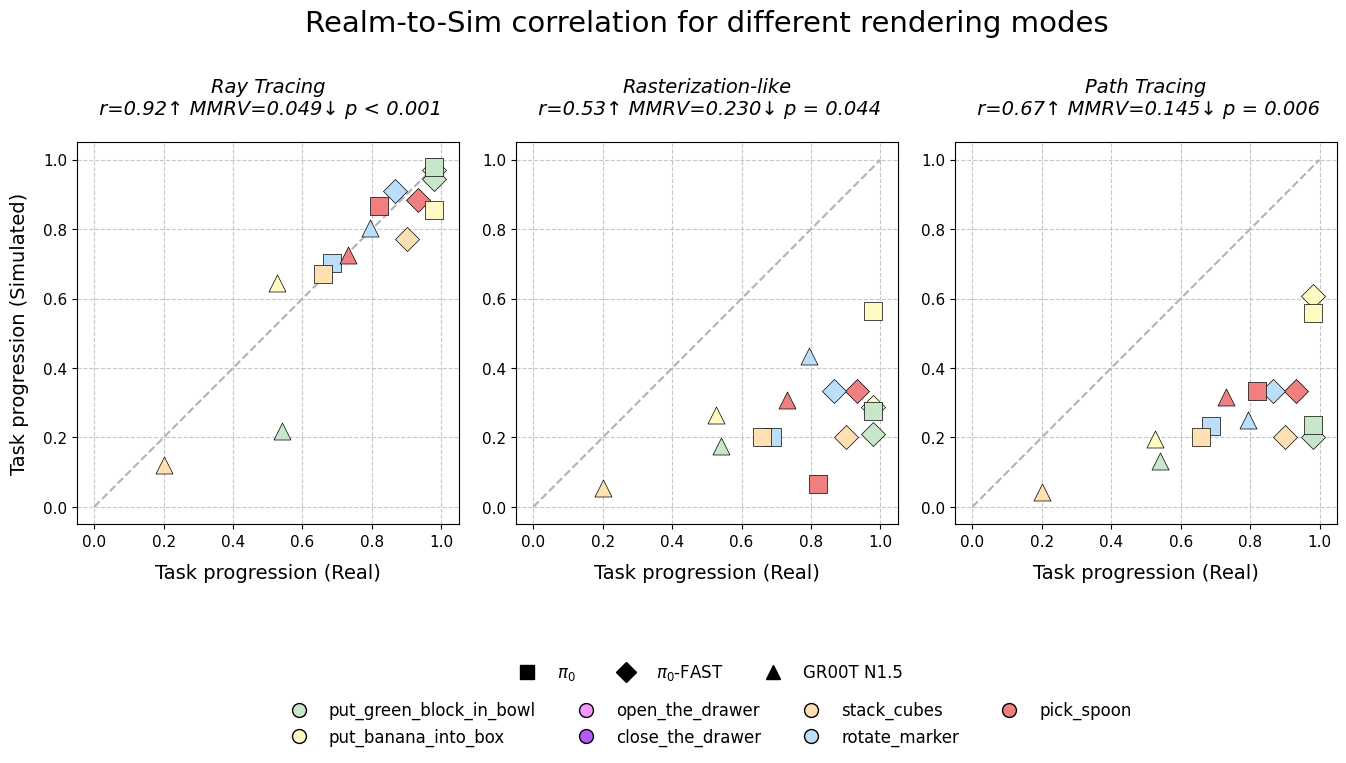

In [15]:
# Row 1: rt / r / pt
fontsize=14
experiments_row1 = ['rt_orig', 'r', 'pt']
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 8)) 
fig1.suptitle('Realm-to-Sim correlation for different rendering modes', fontsize=fontsize*1.5, y=0.98)

for i, exp in enumerate(experiments_row1):
    exp_df = paired_data[paired_data["experiment_name"] == exp]
    agg_data_tp = {}
    for _, row in exp_df.iterrows():
        m, t = row['model'], row['task']
        if m not in agg_data_tp: agg_data_tp[m] = {}
        agg_data_tp[m][t] = {"real_task_progression": row["real_task_progression"], "task_progression": row["task_progression"]}
    do_corr_subplot(i, axes1[i], agg_data_tp, "real_task_progression", "task_progression", f"{exp}", model_markers, task_details, experiment_titles=experiment_titles_rendering, fontsize=fontsize)

# Adjust margins: 
plt.subplots_adjust(left=0.08, right=0.92, bottom=0.05, top=1.1, wspace=0.15)

m_h = [plt.Line2D([0], [0], marker=model_markers[m], color='w', label=model_latex[m], markerfacecolor='black', markersize=10, markeredgecolor='black') for m in models]
t_h = [plt.Line2D([0], [0], marker='o', color='w', label=t, markerfacecolor=task_details[t]['color'], markersize=10, markeredgecolor='black') for t in task_details]

# Place legends within the reserved bottom space without overlapping
fig1.legend(handles=m_h, loc='lower center', bbox_to_anchor=(0.5, 0.12), ncol=3, frameon=False, fontsize=12)
fig1.legend(handles=t_h, loc='lower center', bbox_to_anchor=(0.5, 0.04), ncol=4, frameon=False, fontsize=12)

plt.savefig('rt_r_pt_correlation.pdf', bbox_inches='tight')
plt.show()

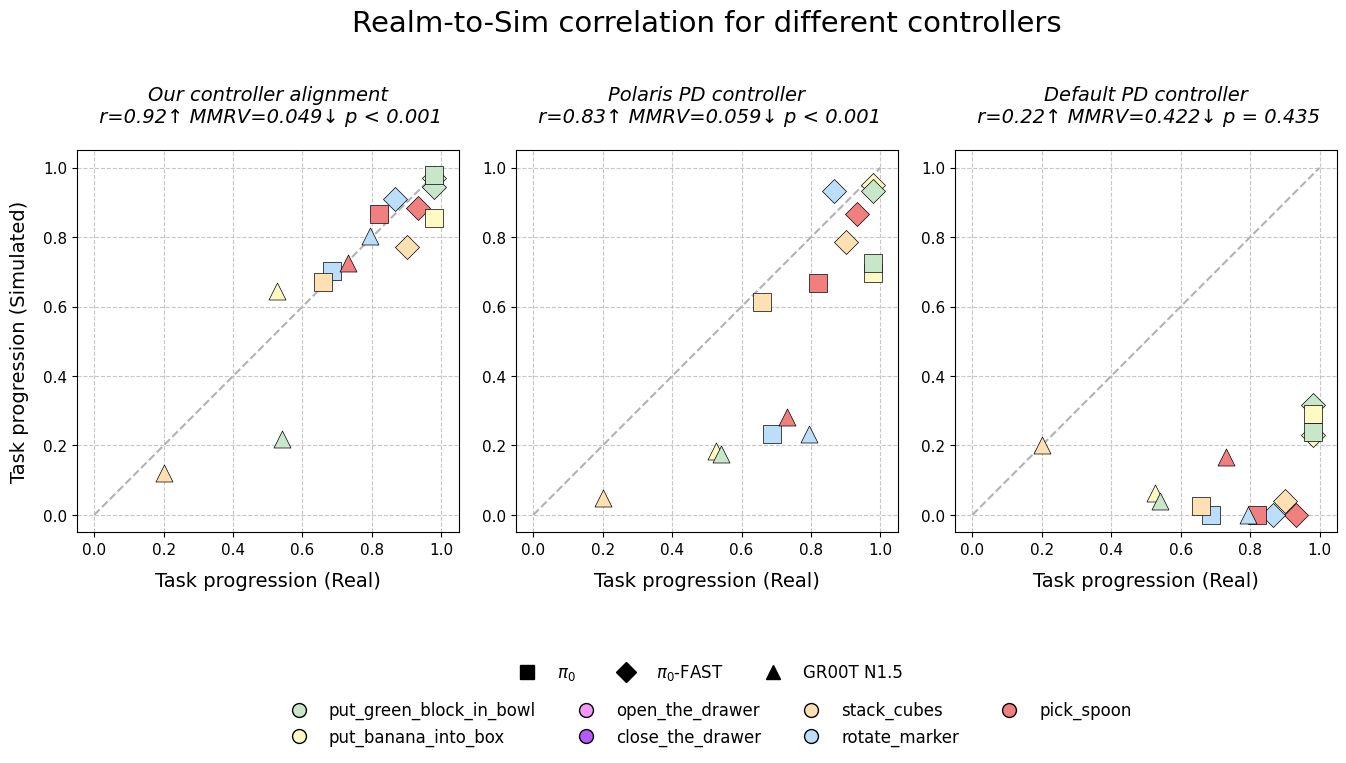

In [16]:
experiments_row2 = ['rt_orig', 'polaris_pd', 'default_pd']
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 8))
fig2.suptitle('Realm-to-Sim correlation for different controllers', fontsize=fontsize*1.5, y=0.98)

for i, exp in enumerate(experiments_row2):
    exp_df = paired_data[paired_data["experiment_name"] == exp]
    agg_data_tp = {}
    for _, row in exp_df.iterrows():
        m, t = row['model'], row['task']
        if m not in agg_data_tp: agg_data_tp[m] = {}
        agg_data_tp[m][t] = {
            "real_task_progression": row["real_task_progression"],
            "task_progression": row["task_progression"]
        }
    do_corr_subplot(i, axes2[i], agg_data_tp, "real_task_progression", "task_progression", f"{exp}", model_markers, task_details, experiment_titles=experiment_titles_control, fontsize=fontsize)

plt.subplots_adjust(left=0.08, right=0.92, bottom=0.25, top=0.88, wspace=0.15)

m_h = [plt.Line2D([0], [0], marker=model_markers[m], color='w', label=model_latex[m], markerfacecolor='black', markersize=10, markeredgecolor='black') for m in models]
t_h = [plt.Line2D([0], [0], marker='o', color='w', label=t, markerfacecolor=task_details[t]['color'], markersize=10, markeredgecolor='black') for t in task_details]

fig2.legend(handles=m_h, loc='lower center', bbox_to_anchor=(0.5, 0.12), ncol=3, frameon=False, fontsize=12)
fig2.legend(handles=t_h, loc='lower center', bbox_to_anchor=(0.5, 0.04), ncol=4, frameon=False, fontsize=12)

plt.savefig('rt_polaris_pd_default_pd_correlation.pdf', bbox_inches='tight')
plt.show()